In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/FraudDetection_project/dat                               ')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Parsing dates... this might take a minute.


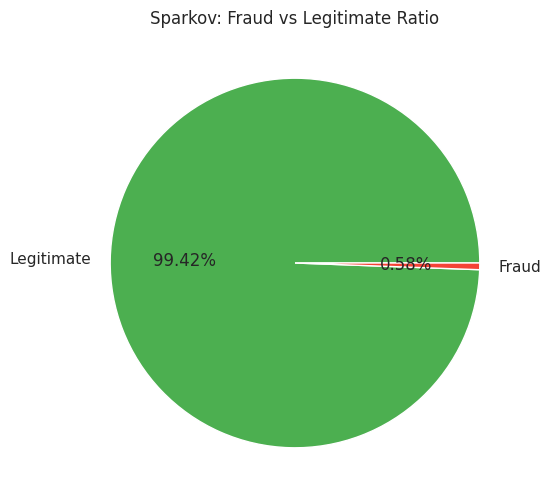

Comment: This proves the severe class imbalance (~0.52% fraud) mentioned in the architecture.


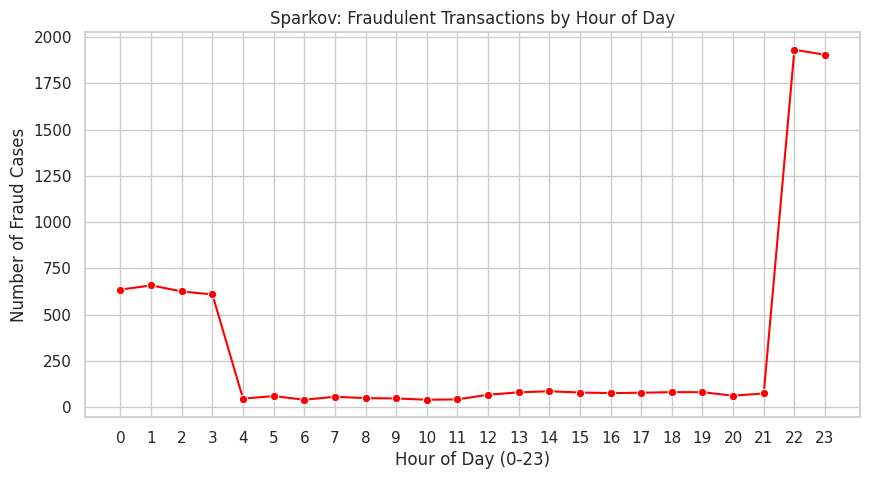

Comment: Notice the spike in unusual hours (typically 10 PM - 3 AM). This validates using transaction_hour as a feature.


/tmp/ipykernel_1256/2498308660.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_fraud_rate.values, y=category_fraud_rate.index, palette='Reds_r')


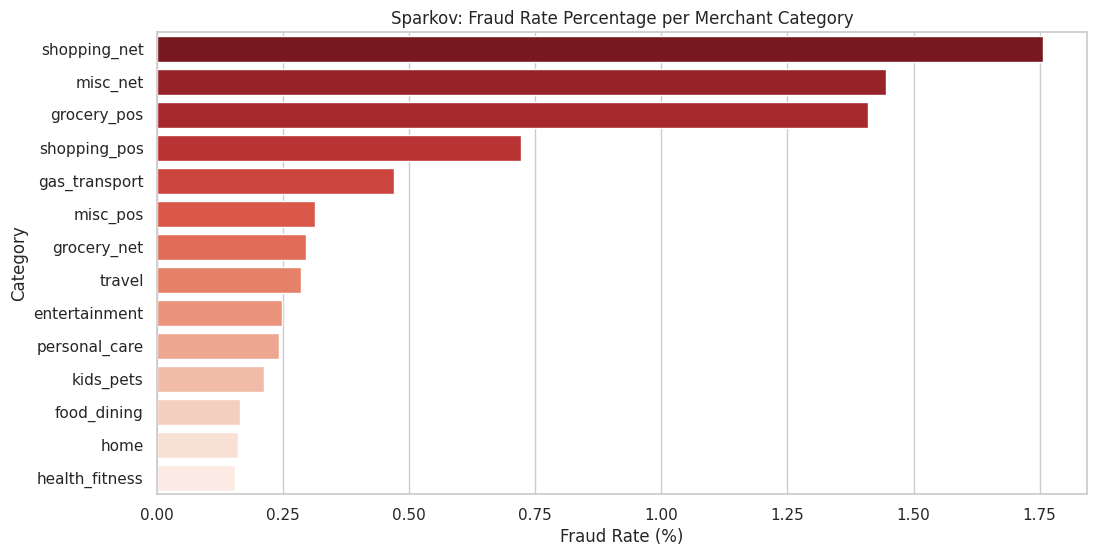

Comment: Highlights which categories (e.g., shopping_net, grocery_pos) are highest risk.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define updated paths
base_path = '/content/drive/MyDrive/FraudDetection_project/datasets/'
output_path = '/content/drive/MyDrive/FraudDetection_project/outputs/'

# Ensure output directory exists
os.makedirs(output_path, exist_ok=True)

# 1. Quick Date Parsing (Required for time-based EDA)
print("Parsing dates... this might take a minute.")
sparkov_train['trans_date_trans_time'] = pd.to_datetime(sparkov_train['trans_date_trans_time'])
sparkov_train['transaction_hour'] = sparkov_train['trans_date_trans_time'].dt.hour

# Set visual style
sns.set_theme(style="whitegrid")

# --- PLOT 1: Class Imbalance (Pie Chart) ---
plt.figure(figsize=(6, 6))
fraud_counts = sparkov_train['is_fraud'].value_counts()
plt.pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%', colors=['#4CAF50', '#F44336'])
plt.title('Sparkov: Fraud vs Legitimate Ratio')
plt.savefig(output_path + 'sparkov_1_class_imbalance.png', bbox_inches='tight')
plt.show()
print("Comment: This proves the severe class imbalance (~0.52% fraud) mentioned in the architecture.")

# --- PLOT 2: Fraud by Hour of Day (Line Chart) ---
plt.figure(figsize=(10, 5))
hourly_fraud = sparkov_train[sparkov_train['is_fraud'] == 1].groupby('transaction_hour').size()
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values, color='red', marker='o')
plt.title('Sparkov: Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraud Cases')
plt.xticks(range(0, 24))
plt.savefig(output_path + 'sparkov_2_fraud_by_hour.png', bbox_inches='tight')
plt.show()
print("Comment: Notice the spike in unusual hours (typically 10 PM - 3 AM). This validates using transaction_hour as a feature.")

# --- PLOT 3: Fraud Rate by Merchant Category (Bar Chart) ---
plt.figure(figsize=(12, 6))
category_fraud_rate = sparkov_train.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
sns.barplot(x=category_fraud_rate.values, y=category_fraud_rate.index, palette='Reds_r')
plt.title('Sparkov: Fraud Rate Percentage per Merchant Category')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Category')
plt.savefig(output_path + 'sparkov_3_fraud_by_category.png', bbox_inches='tight')
plt.show()
print("Comment: Highlights which categories (e.g., shopping_net, grocery_pos) are highest risk.")

/tmp/ipykernel_1256/3419392161.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_fraud.index, y=type_fraud.values, palette='Oranges_r')


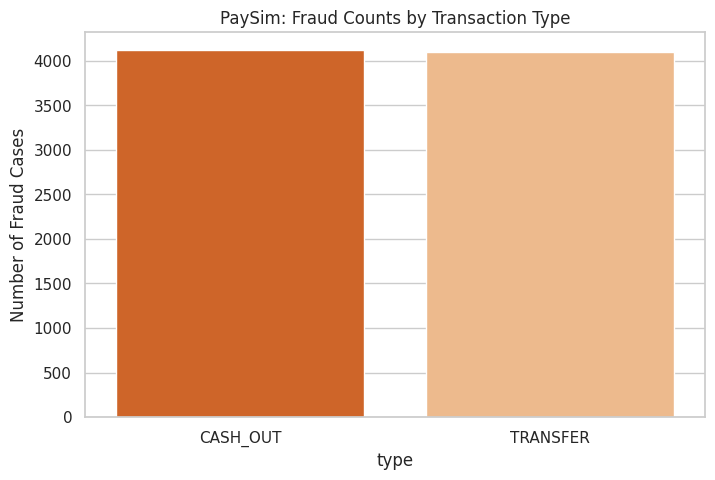

Comment: Visually proves that fraud ONLY happens in TRANSFER and CASH_OUT types.

Total actual fraud cases: 8213
Cases correctly flagged by isFlaggedFraud: 16
Comment: Since the system flag catches almost zero actual fraud cases, we can safely drop it from our modeling features as per the architecture diagram.


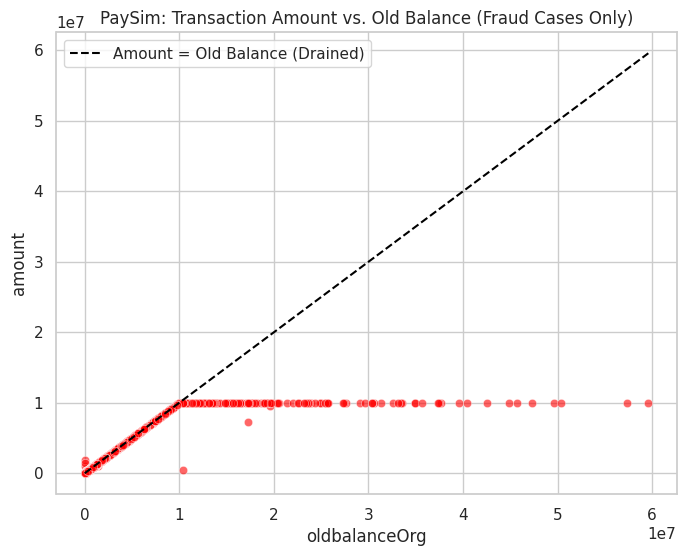

Comment: The clustering along the dashed line proves that fraudsters typically transfer the exact total balance available to wipe the account to zero.


In [ ]:
# Assuming paysim_data is already loaded from Step 1
# (If you restarted your runtime, you will need to re-run the Step 1 loading code first)

# --- PLOT 4: Fraud by Transaction Type (Bar Chart) ---
plt.figure(figsize=(8, 5))
type_fraud = paysim_data[paysim_data['isFraud'] == 1]['type'].value_counts()
sns.barplot(x=type_fraud.index, y=type_fraud.values, palette='Oranges_r')
plt.title('PaySim: Fraud Counts by Transaction Type')
plt.ylabel('Number of Fraud Cases')
plt.savefig(output_path + 'paysim_1_fraud_by_type.png', bbox_inches='tight')
plt.show()
print("Comment: Visually proves that fraud ONLY happens in TRANSFER and CASH_OUT types.")

# --- PLOT 5: Proving isFlaggedFraud is Useless ---
flagged_fraud_cases = paysim_data[(paysim_data['isFraud'] == 1) & (paysim_data['isFlaggedFraud'] == 1)]
print(f"\nTotal actual fraud cases: {paysim_data['isFraud'].sum()}")
print(f"Cases correctly flagged by isFlaggedFraud: {len(flagged_fraud_cases)}")
print("Comment: Since the system flag catches almost zero actual fraud cases, we can safely drop it from our modeling features as per the architecture diagram.")

# --- PLOT 6: Balance Drained Behavior (Scatter/KDE) ---
# Filtering to just a sample of fraud transfers to see if they drain the account
fraud_transfers = paysim_data[(paysim_data['isFraud'] == 1) & (paysim_data['type'] == 'TRANSFER')]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=fraud_transfers, x='oldbalanceOrg', y='amount', alpha=0.6, color='red')
# Draw a reference line where Amount == Old Balance (meaning the account was completely drained)
plt.plot([0, fraud_transfers['oldbalanceOrg'].max()], [0, fraud_transfers['oldbalanceOrg'].max()],
         color='black', linestyle='--', label='Amount = Old Balance (Drained)')
plt.title('PaySim: Transaction Amount vs. Old Balance (Fraud Cases Only)')
plt.legend()
plt.savefig(output_path + 'paysim_2_balance_drained.png', bbox_inches='tight')
plt.show()
print("Comment: The clustering along the dashed line proves that fraudsters typically transfer the exact total balance available to wipe the account to zero.")

/tmp/ipykernel_1256/916693561.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])


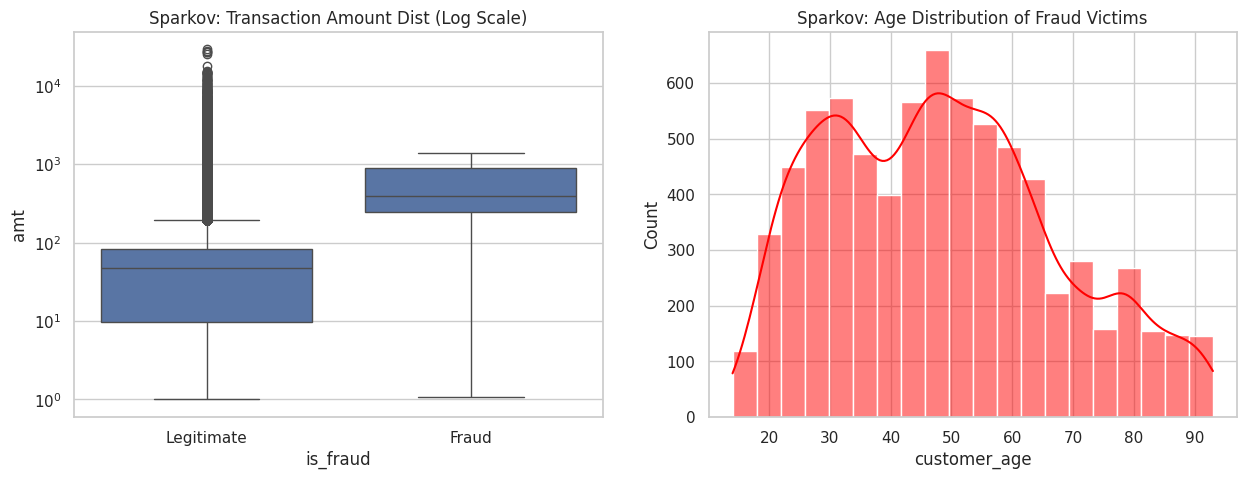

/tmp/ipykernel_1256/916693561.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=gender_fraud.index, y=gender_fraud.values, palette='viridis')


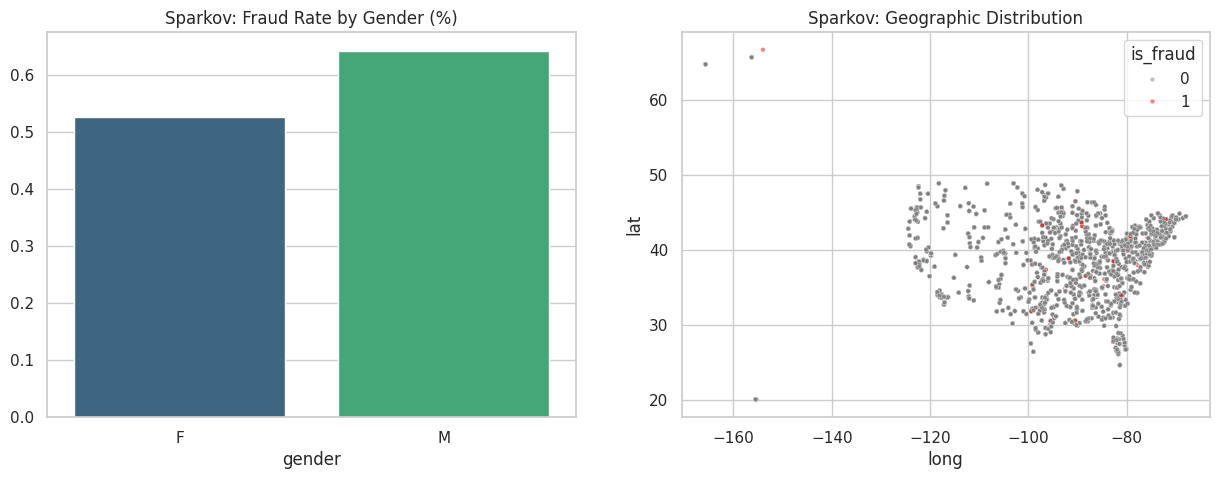

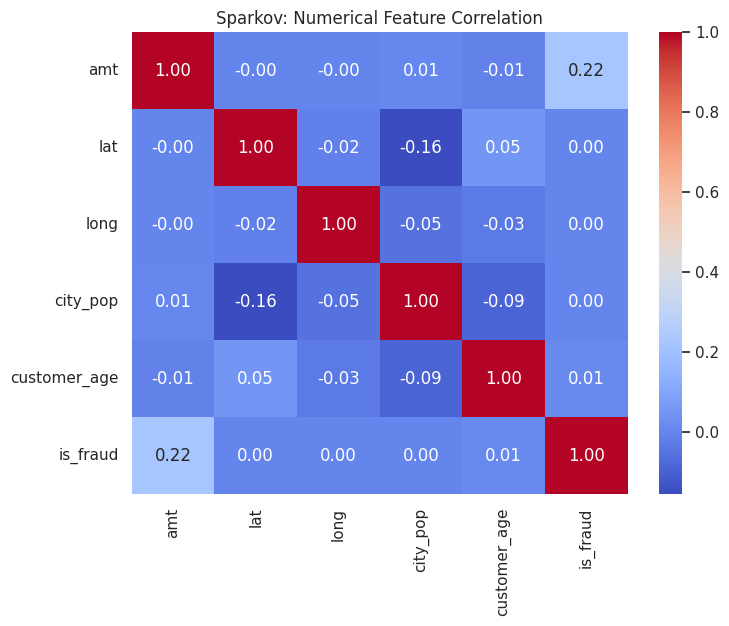

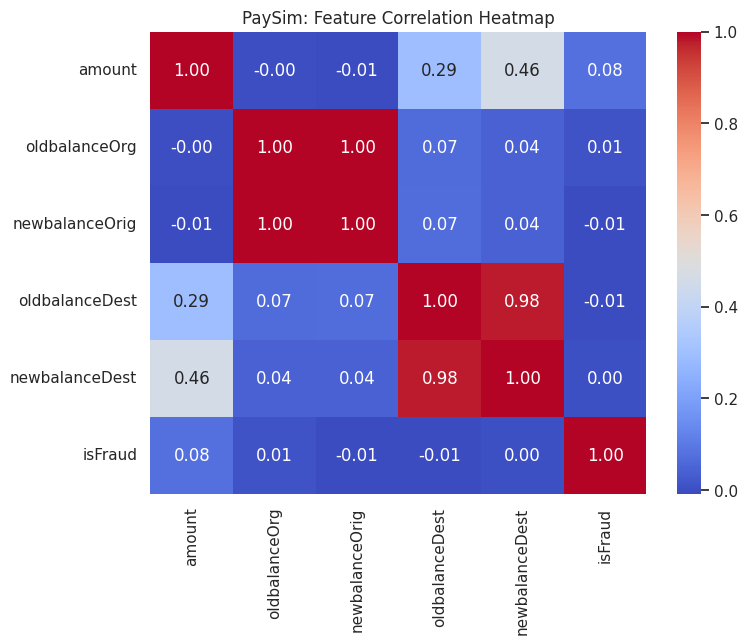

Comment: Phase 1 EDA is now strictly aligned with all diagram requirements.


In [ ]:
import numpy as np

# --- SPARKOV MISSING EDA ---

# 1. Age and Amount Distribution
# Calculate age first
sparkov_train['dob'] = pd.to_datetime(sparkov_train['dob'])
sparkov_train['customer_age'] = (sparkov_train['trans_date_trans_time'] - sparkov_train['dob']).dt.days // 365

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Amount distribution (using log scale because fraud amounts can be huge)
sns.boxplot(ax=axes[0], data=sparkov_train, x='is_fraud', y='amt')
axes[0].set_yscale('log')
axes[0].set_title('Sparkov: Transaction Amount Dist (Log Scale)')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

# Age distribution
sns.histplot(ax=axes[1], data=sparkov_train[sparkov_train['is_fraud'] == 1], x='customer_age', bins=20, color='red', kde=True)
axes[1].set_title('Sparkov: Age Distribution of Fraud Victims')

plt.savefig(output_path + 'sparkov_4_amount_and_age.png', bbox_inches='tight')
plt.show()

# 2. Gender and Geography
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gender
gender_fraud = sparkov_train.groupby('gender')['is_fraud'].mean() * 100
sns.barplot(ax=axes[0], x=gender_fraud.index, y=gender_fraud.values, palette='viridis')
axes[0].set_title('Sparkov: Fraud Rate by Gender (%)')

# Geographic Scatter (taking a sample so it doesn't crash RAM)
geo_sample = sparkov_train.sample(n=50000, random_state=42)
sns.scatterplot(ax=axes[1], data=geo_sample, x='long', y='lat', hue='is_fraud', palette={0: 'gray', 1: 'red'}, alpha=0.5, s=10)
axes[1].set_title('Sparkov: Geographic Distribution')

plt.savefig(output_path + 'sparkov_5_gender_and_geo.png', bbox_inches='tight')
plt.show()

# 3. Sparkov Correlation Heatmap
plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation
sparkov_num = sparkov_train[['amt', 'lat', 'long', 'city_pop', 'customer_age', 'is_fraud']]
sns.heatmap(sparkov_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sparkov: Numerical Feature Correlation')
plt.savefig(output_path + 'sparkov_6_correlation.png', bbox_inches='tight')
plt.show()

# --- PAYSIM MISSING EDA ---

# 1. PaySim Correlation Heatmap
plt.figure(figsize=(8, 6))
paysim_num = paysim_data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']]
sns.heatmap(paysim_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('PaySim: Feature Correlation Heatmap')
plt.savefig(output_path + 'paysim_3_correlation.png', bbox_inches='tight')
plt.show()

print("Comment: Phase 1 EDA is now strictly aligned with all diagram requirements.")